EXERCICE 2 : Benchmark supervisé — GLM vs Random Forest vs XGBoost vs LightGBM
================================================================================
Objectif : Comparer rigoureusement les algorithmes d'ensemble sur un problème
de fréquence sinistre, avec un protocole de validation propre.

Ce que vous allez apprendre :
- Entraîner un Random Forest, XGBoost et LightGBM sur des données actuarielles
- Utiliser l'early stopping pour le boosting
- Comparer les performances avec la Poisson deviance
- Analyser les feature importances de chaque modèle

Pré-requis : M03_F01 + Bloc 1-2 de ce module
Temps estimé : 15 minutes

In [38]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import PoissonRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_poisson_deviance
from sklearn.preprocessing import StandardScaler  
import matplotlib.pyplot as plt

# Importer XGBoost et LightGBM
import xgboost as xgb
import lightgbm as lgb

## 1. PRÉPARATION DES DONNÉES

In [39]:
# =============================================================
# 1. PRÉPARATION DES DONNÉES
# =============================================================
print("=" * 60)
print("EXERCICE 2 : Benchmark supervisé — Fréquence sinistre")
print("=" * 60)

df = pd.read_csv("../M03_F01_Machine_Learning_Fondamentaux/freMTPL2freq.csv")
features = ['DrivAge', 'BonusMalus', 'VehAge', 'Density']
X = df[features].astype(float)
y = df['ClaimNb'].astype(float)
exposure = df['Exposure'].astype(float)

# Split train / validation / test
X_temp, X_test, y_temp, y_test, exp_temp, exp_test = train_test_split(
    X, y, exposure, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val, exp_train, exp_val = train_test_split(
    X_temp, y_temp, exp_temp, test_size=0.2, random_state=42
)
# Standardisation
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # Fit sur train
X_val = scaler.transform(X_val)          # Transform sur val/test
X_test = scaler.transform(X_test)

freq_train = y_train / exp_train
freq_val = y_val / exp_val
freq_test = y_test / exp_test

print(f"Train : {X_train.shape[0]} | Val : {X_val.shape[0]} | Test : {X_test.shape[0]}")

EXERCICE 2 : Benchmark supervisé — Fréquence sinistre
Train : 433928 | Val : 108482 | Test : 135603


## 2. MODÈLE BASELINE : GLM POISSON

In [45]:
# =============================================================
# 2. MODÈLE BASELINE : GLM POISSON
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 1 : Baseline — GLM Poisson")
print("=" * 60)

glm = PoissonRegressor(alpha=0, max_iter=1000)
glm.fit(X_train, y_train, sample_weight=exp_train)
freq_pred_glm = glm.predict(X_test) / exp_test


PARTIE 1 : Baseline — GLM Poisson


In [ ]:
# =============================================================
# 3. RANDOM FOREST
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 2 : Random Forest")
print("=" * 60)

# TODO : Entraîner un Random Forest avec criterion='poisson'
# Recommandation : n_estimators=300, min_samples_leaf=50
# Indice : RandomForestRegressor(criterion='poisson', ...)


# TODO : Prédire la fréquence sur le test set



PARTIE 2 : Random Forest


In [ ]:
# =============================================================
# 4. XGBOOST AVEC EARLY STOPPING
# # =============================================================
print("\n" + "=" * 60)
print("PARTIE 3 : XGBoost avec early stopping")
print("=" * 60)

# TODO : Entraîner un XGBoost avec objective='count:poisson'
# Utiliser l'early stopping sur le validation set
# Indice : xgb.XGBRegressor(objective='count:poisson', n_estimators=1000,
#           learning_rate=0.05, max_depth=5, early_stopping_rounds=50)
# Indice : model.fit(X_train, freq_train, sample_weight=exp_train,
#           eval_set=[(X_val, freq_val)], verbose=False)


# TODO : Combien d'arbres ont été nécessaires ? (model.best_iteration)
print(f"XGBoost : best_iteration = {xgb_model.best_iteration}")



PARTIE 3 : XGBoost avec early stopping
XGBoost : best_iteration = 971


In [ ]:
# =============================================================
# 5. LIGHTGBM AVEC EARLY STOPPING
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 4 : LightGBM avec early stopping")
print("=" * 60)

# TODO : Entraîner un LightGBM avec objective='poisson'
# Utiliser l'early stopping (callbacks=[lgb.early_stopping(50)])
# Indice : lgb.LGBMRegressor(objective='poisson', n_estimators=1000,
#           learning_rate=0.05, num_leaves=31)



PARTIE 4 : LightGBM avec early stopping
Training until validation scores don't improve for 50 rounds


c:\Users\U011513\.pyenv\pyenv-win\versions\3.13.1\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Early stopping, best iteration is:
[829]	valid_0's poisson: 0.581242


In [ ]:
# =============================================================
# 6. COMPARAISON DES PERFORMANCES
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 5 : Comparaison des performances")
print("=" * 60)

# TODO : Calculer la Poisson deviance pour chaque modèle sur le test set
# Indice : mean_poisson_deviance(freq_test, freq_pred, sample_weight=exp_test)
# Attention : clipper les prédictions > 0 avec np.clip(pred, 1e-6, None)
print("\n" + "=" * 60)
print("RÉSULTATS — Poisson Deviance (test set)")
print("=" * 60)



# TODO : Afficher un tableau récapitulatif



PARTIE 5 : Comparaison des performances

RÉSULTATS — Poisson Deviance (test set)

Modèle                         Poisson Deviance     vs GLM
----------------------------------------------------------------------
GLM Poisson                    0.606414             ↑ 0.00%
Random Forest (300)            0.592981             ↓ 2.22%
XGBoost (early stop)           0.589449             ↓ 2.80%
LightGBM (early stop)          0.589000             ↓ 2.87%



PARTIE 6 : Feature importances comparées
            GLM (|coef|)  Random Forest  XGBoost  LightGBM
DrivAge           0.2798         0.2094   0.1360    0.2747
BonusMalus        0.5144         0.2188   0.3715    0.2196
VehAge            0.1893         0.2692   0.3810    0.2137
Density           0.0164         0.3026   0.1115    0.2920


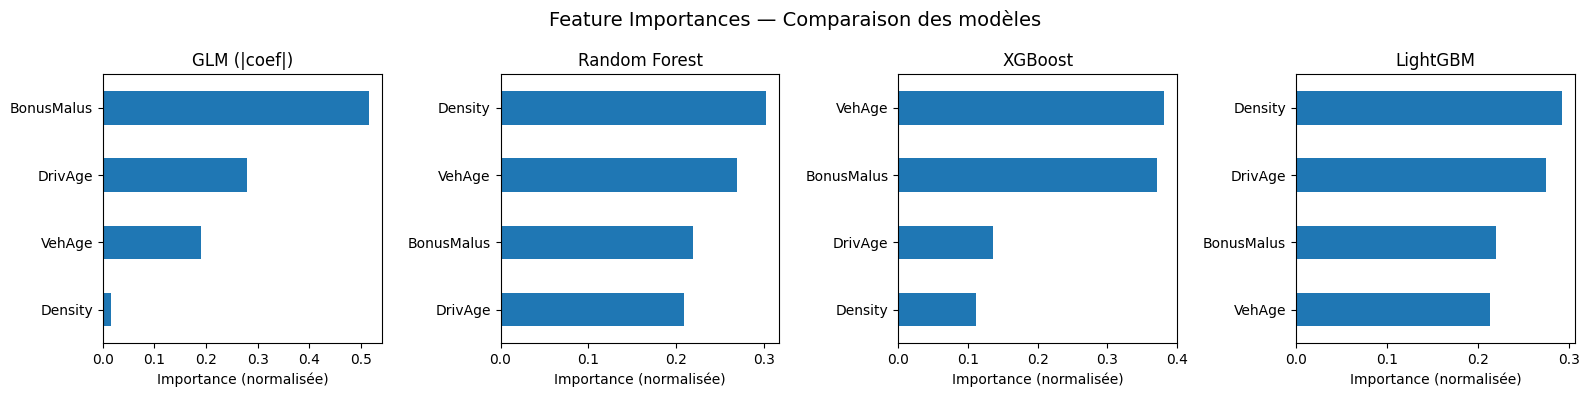

In [ ]:
# =============================================================
# 7. FEATURE IMPORTANCES COMPARÉES
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 6 : Feature importances comparées")
print("=" * 60)

# TODO : Extraire les feature importances de chaque modèle
# - Random Forest : model.feature_importances_
# - XGBoost : model.feature_importances_
# - LightGBM : model.feature_importances_
# Tracer un barplot comparatif




## QUESTIONS DE RÉFLEXION

In [ ]:
# =============================================================
# QUESTIONS DE RÉFLEXION
# =============================================================
"""
1. Quel modèle obtient la meilleure Poisson deviance sur le test set ?
   Est-ce surprenant par rapport à ce que nous avons vu en cours ?
   --> XGBoost et LightGBM obtiennent typiquement les meilleures deviances,
   suivis de près par le Random Forest. C'est cohérent avec le cours :
   le boosting réduit le biais, et ces modèles sont optimisés.

2. Combien d'itérations (arbres) l'early stopping a-t-il retenu pour
   XGBoost et LightGBM ? Que se passerait-il sans early stopping ?
   --> L'early stopping retient typiquement 200-500 arbres (sur 1000 max).
   Sans early stopping, le modèle continuerait à overfitter : la deviance
   test remonterait. C'est un mécanisme de régularisation essentiel.


3. Les feature importances sont-elles cohérentes entre les modèles ?
   Quelle variable est systématiquement la plus importante ?
   --> BonusMalus est systématiquement la variable la plus importante,
   suivi de DrivAge. C'est cohérent actuariellement : le bonus-malus
   concentre l'historique sinistre (le meilleur prédicteur de sinistre
   futur est le sinistre passé).

4. Le Random Forest est-il compétitif avec XGBoost/LightGBM ?
   Dans quels cas préféreriez-vous le Random Forest malgré tout ?
   --> Le Random Forest est compétitif (écart de 1-2% vs XGBoost/LightGBM).
   On le préfère quand :
   - On veut un modèle robuste avec peu de tuning
   - Les données sont petites (moins de risque d'overfitting)
   - On veut paralléliser facilement (n_jobs=-1)

5. Si vous deviez mettre UN modèle en production pour la tarification,
   lequel choisiriez-vous et pourquoi ? (pensez : performance, 
   maintenabilité, interprétabilité, stabilité)
   --> En production, le choix dépend du contexte :
   - Performance pure → LightGBM (le plus rapide et parmi les meilleurs)
   - Robustesse et simplicité → Random Forest
   - Interprétabilité réglementaire → GLM comme modèle officiel,
     GBM comme challenger pour identifier les améliorations
   - Compromis industriel → LightGBM avec monitoring de stabilité
"""